<a href="https://colab.research.google.com/github/Friskkun/Project-coding-storage/blob/main/q_table_visualize.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training finished.
Final tau = 0.02
Shared Q-table shape = (448, 2)
Average reward per agent over last 5000 steps:
[0.4288 0.4284 0.4286 0.4288 0.4284 0.4286 0.4284]
Overall average reward across agents:
0.42857142857142855


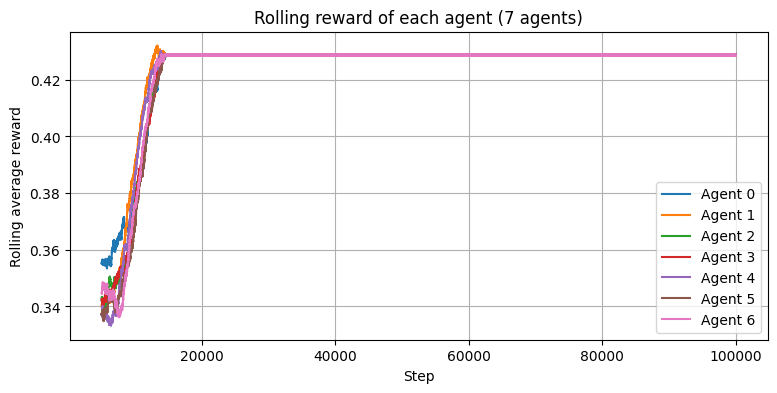

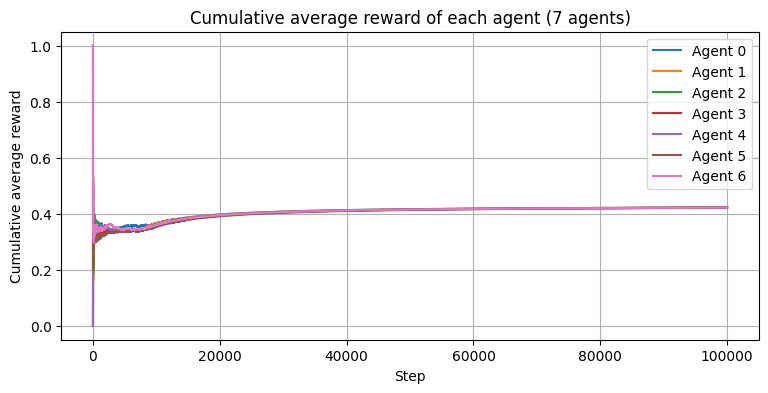

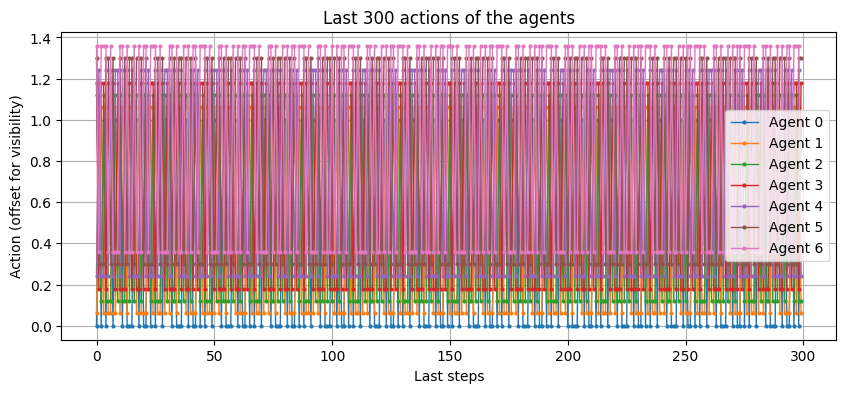

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Shared-Q Minority Game with:
#   - arbitrary number of agents
#   - shared Q-table
#   - phase information: phi_i(t) = (i + t) % phase_size
#   - reward-related state: recent reward history of each agent
#   - softmax action selection
# =========================================================


class MinorityGameSharedQPhase:
    def __init__(self, m=7, n_agents=7, reward_hist_len=2, phase_size=None, seed=0):
        self.m = int(m)
        self.n_agents = int(n_agents)
        self.reward_hist_len = int(reward_hist_len)

        # if phase_size is not given, default to n_agents
        self.phase_size = int(phase_size) if phase_size is not None else int(n_agents)

        self.base_states = 2 ** self.m
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        # public history of minority actions
        self.public_hist = 0

        # time index
        self.t = 0

        # each agent's recent reward history, binary vector of length reward_hist_len
        self.reward_hist = np.zeros((self.n_agents, self.reward_hist_len), dtype=int)

        return self.get_states()

    def encode_binary_vec(self, vec):
        """
        Encode a binary vector into an integer.
        Example:
            [0,1] -> 1
            [1,0] -> 2
            [1,1] -> 3
        """
        x = 0
        for v in vec:
            x = (x << 1) | int(v)
        return x

    def phase_of_agent(self, i):
        """
        Rotating phase:
            phi_i(t) = (i + t) % phase_size
        """
        return (i + self.t) % self.phase_size

    def encode_state(self, public_hist, phase, reward_hist_code):
        """
        State = (public_hist, phase, reward_hist_code)

        public_hist      in [0, 2^m - 1]
        phase            in [0, phase_size - 1]
        reward_hist_code in [0, 2^reward_hist_len - 1]
        """
        return (public_hist * self.phase_size + phase) * (2 ** self.reward_hist_len) + reward_hist_code

    def get_states(self):
        states = np.zeros(self.n_agents, dtype=int)
        for i in range(self.n_agents):
            phase = self.phase_of_agent(i)
            reward_hist_code = self.encode_binary_vec(self.reward_hist[i])
            states[i] = self.encode_state(self.public_hist, phase, reward_hist_code)
        return states

    def step(self, actions):
        """
        Minority game rule:
            - minority side gets reward 1
            - majority side gets reward 0
            - if tie (possible when n_agents is even), all get reward 0
        """
        actions = np.asarray(actions, dtype=int)
        assert actions.shape == (self.n_agents,)

        n0 = np.sum(actions == 0)
        n1 = np.sum(actions == 1)

        rewards = np.zeros(self.n_agents, dtype=float)

        if n0 < n1:
            minority_action = 0
            rewards[actions == 0] = 1.0
        elif n1 < n0:
            minority_action = 1
            rewards[actions == 1] = 1.0
        else:
            # tie case for even number of agents
            minority_action = 0
            # all rewards remain 0

        # update public history with minority action
        self.public_hist = ((self.public_hist << 1) & (self.base_states - 1)) | minority_action

        # update reward histories
        rewards_int = rewards.astype(int)
        if self.reward_hist_len > 1:
            self.reward_hist[:, :-1] = self.reward_hist[:, 1:]
        self.reward_hist[:, -1] = rewards_int

        # time moves forward
        self.t += 1

        next_states = self.get_states()
        return next_states, rewards, minority_action


def softmax_action(Q, state, tau, rng):
    q = Q[state]
    q_shift = q - np.max(q)   # numerical stability
    prob = np.exp(q_shift / tau)
    prob = prob / prob.sum()
    return rng.choice([0, 1], p=prob)


def run_shared_q_phase(
    m=7,
    n_agents=7,
    steps=100000,
    seed=42,
    alpha=0.10,
    gamma=0.95,
    tau_start=1.0,
    tau_end=0.02,
    tau_decay=0.99995,
    reward_hist_len=2,
    phase_size=None,
    log_window=1000
):
    env = MinorityGameSharedQPhase(
        m=m,
        n_agents=n_agents,
        reward_hist_len=reward_hist_len,
        phase_size=phase_size,
        seed=seed
    )

    n_states = (2 ** m) * env.phase_size * (2 ** reward_hist_len)
    n_actions = 2

    # one shared Q-table
    Q = np.zeros((n_states, n_actions), dtype=float)

    states = env.reset()
    tau = tau_start

    rewards_hist = np.zeros((steps, n_agents), dtype=float)
    actions_hist = np.zeros((steps, n_agents), dtype=int)
    minority_hist = np.zeros(steps, dtype=int)
    tau_hist = np.zeros(steps, dtype=float)

    for t in range(steps):
        actions = np.zeros(n_agents, dtype=int)

        # all agents use the same Q-table
        for i in range(n_agents):
            actions[i] = softmax_action(Q, states[i], tau, env.rng)

        next_states, rewards, minority_action = env.step(actions)

        # shared Q update
        for i in range(n_agents):
            s = states[i]
            a = actions[i]
            r = rewards[i]
            s_next = next_states[i]

            td_target = r + gamma * np.max(Q[s_next])
            Q[s, a] += alpha * (td_target - Q[s, a])

        rewards_hist[t] = rewards
        actions_hist[t] = actions
        minority_hist[t] = minority_action
        tau_hist[t] = tau

        states = next_states
        tau = max(tau_end, tau * tau_decay)

    # rolling average reward of each agent
    rolling_rewards = np.full((steps, n_agents), np.nan)
    if log_window <= steps:
        kernel = np.ones(log_window) / log_window
        for i in range(n_agents):
            rolling_rewards[log_window - 1:, i] = np.convolve(
                rewards_hist[:, i], kernel, mode='valid'
            )

    return Q, rewards_hist, actions_hist, minority_hist, rolling_rewards, tau_hist


# =========================================================
# Run experiment
# =========================================================
Q, rewards_hist, actions_hist, minority_hist, rolling_rewards, tau_hist = run_shared_q_phase(
    m=3,
    n_agents=7,          # <- now you can change this freely
    steps=100000,
    seed=123,
    alpha=0.10,
    gamma=0.95,
    tau_start=1.0,
    tau_end=0.02,
    tau_decay=0.9999,
    reward_hist_len=3,
    phase_size=7,        # usually you may set this equal to n_agents
    log_window=5000
)

print("Training finished.")
print("Final tau =", tau_hist[-1])
print("Shared Q-table shape =", Q.shape)
print("Average reward per agent over last 5000 steps:")
print(rewards_hist[-5000:].mean(axis=0))
print("Overall average reward across agents:")
print(rewards_hist[-5000:].mean())


# =========================================================
# Plot 1: rolling reward of each agent
# =========================================================
plt.figure(figsize=(9, 4))
for i in range(rewards_hist.shape[1]):
    plt.plot(rolling_rewards[:, i], label=f"Agent {i}")
plt.xlabel("Step")
plt.ylabel("Rolling average reward")
plt.title(f"Rolling reward of each agent ({rewards_hist.shape[1]} agents)")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# Plot 2: cumulative average reward
# =========================================================
cum_avg_rewards = np.cumsum(rewards_hist, axis=0) / (np.arange(len(rewards_hist))[:, None] + 1)

plt.figure(figsize=(9, 4))
for i in range(rewards_hist.shape[1]):
    plt.plot(cum_avg_rewards[:, i], label=f"Agent {i}")
plt.xlabel("Step")
plt.ylabel("Cumulative average reward")
plt.title(f"Cumulative average reward of each agent ({rewards_hist.shape[1]} agents)")
plt.legend()
plt.grid(True)
plt.show()


# =========================================================
# Plot 3: last 300 actions
# =========================================================
last = 300
tail_actions = actions_hist[-last:]

plt.figure(figsize=(10, 4))
for i in range(tail_actions.shape[1]):
    plt.plot(
        np.arange(last),
        tail_actions[:, i] + 0.06 * i,
        marker='o',
        markersize=2,
        linewidth=1,
        label=f"Agent {i}"
    )
plt.xlabel("Last steps")
plt.ylabel("Action (offset for visibility)")
plt.title(f"Last {last} actions of the agents")
plt.legend()
plt.grid(True)
plt.show()

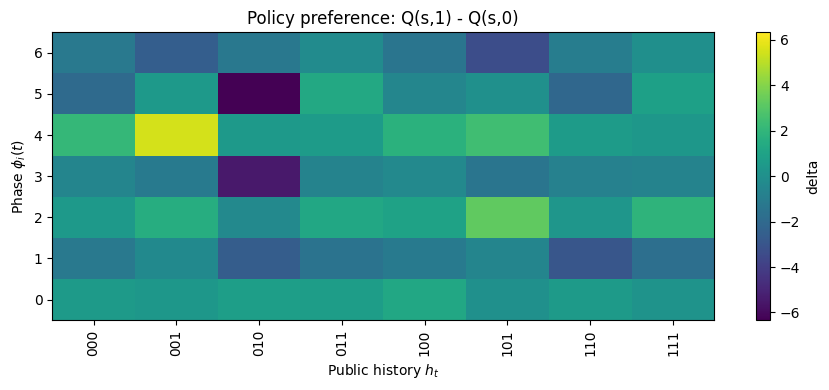

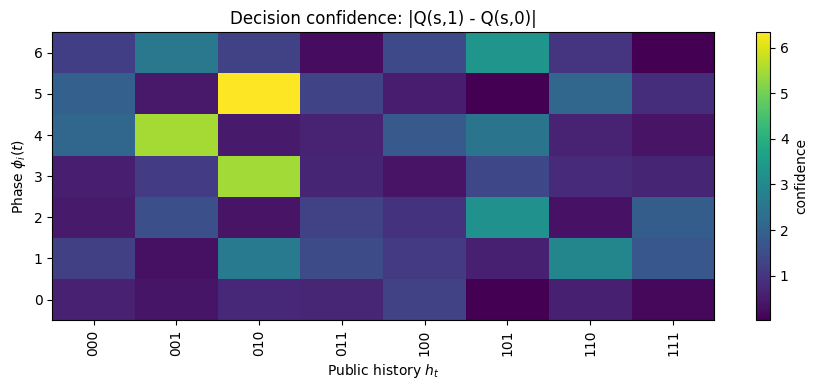

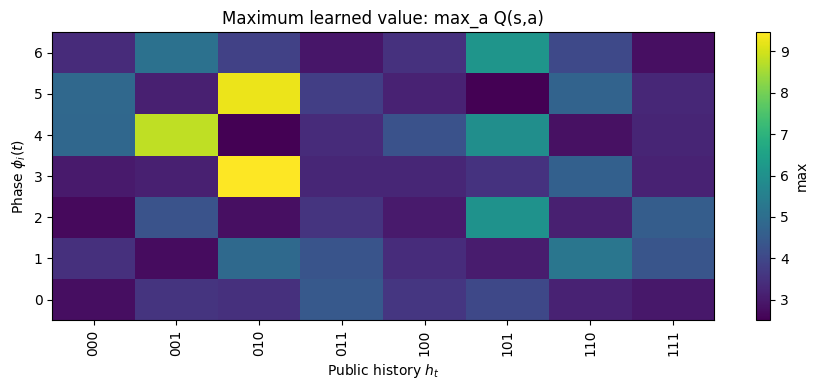

/tmp/ipykernel_3931/706026676.py:294: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


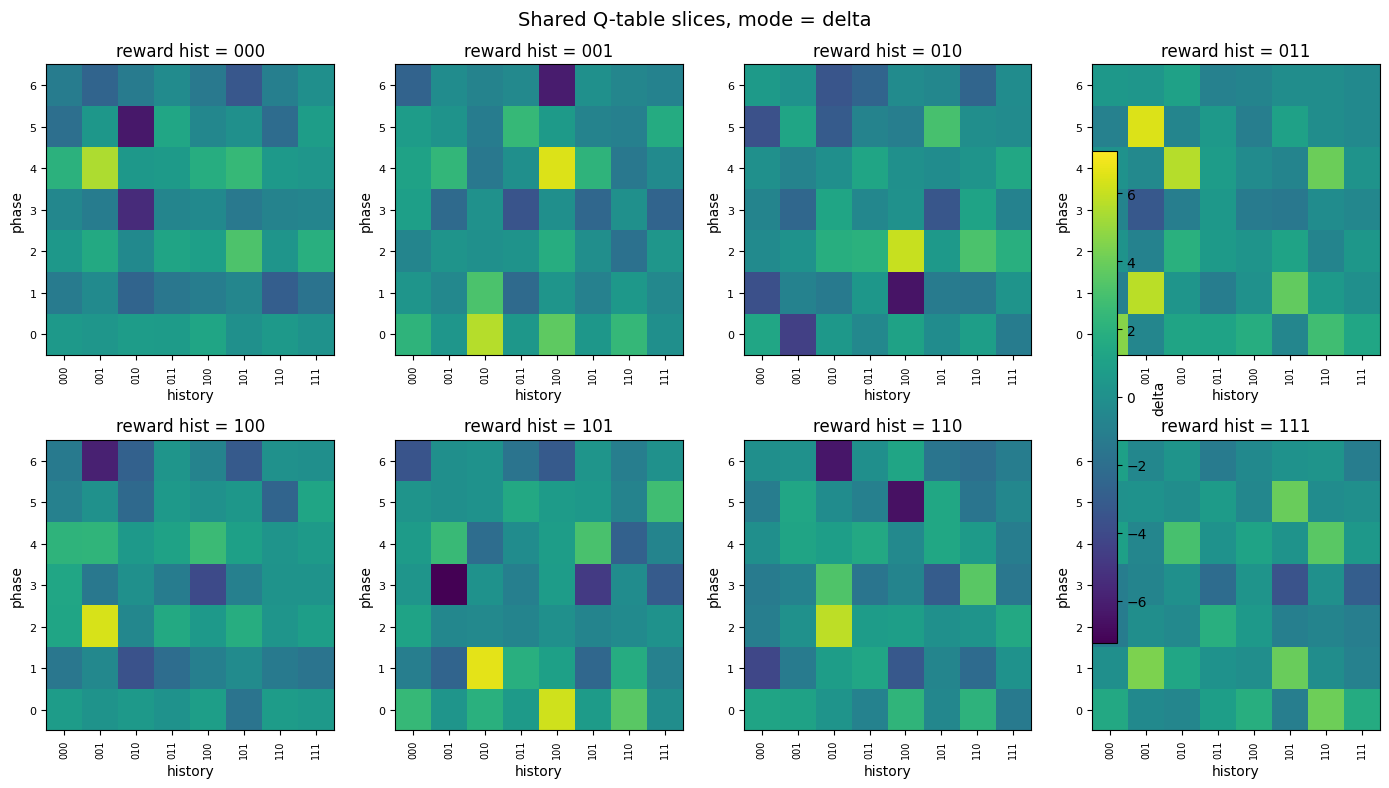

/tmp/ipykernel_3931/706026676.py:294: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


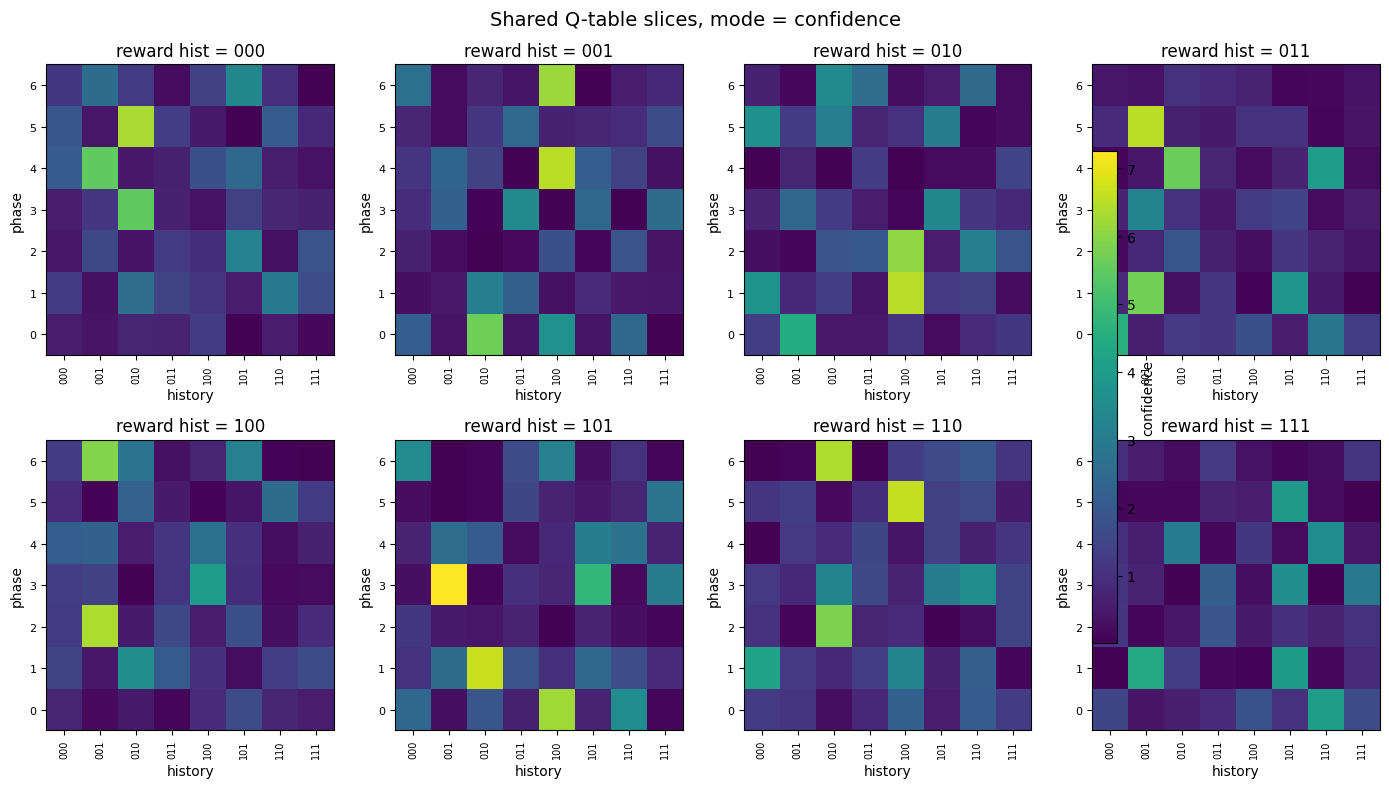

Q-table density report
Q-table shape: (448, 2)
Total number of Q-values: 896

Threshold |Q| > 1e-06: density = 1.0000, count = 896/896
Threshold |Q| > 0.0001: density = 1.0000, count = 896/896
Threshold |Q| > 0.001: density = 1.0000, count = 896/896
Threshold |Q| > 0.01: density = 1.0000, count = 896/896
Threshold |Q| > 0.1: density = 1.0000, count = 896/896
Threshold |Q| > 1: density = 0.9185, count = 823/896
Effective policy density report
Total number of states: 448

Threshold |Delta Q| > 0.001: density = 0.9978, count = 447/448
Threshold |Delta Q| > 0.01: density = 0.9911, count = 444/448
Threshold |Delta Q| > 0.05: density = 0.9487, count = 425/448
Threshold |Delta Q| > 0.1: density = 0.9219, count = 413/448
Threshold |Delta Q| > 1: density = 0.4643, count = 208/448
Threshold |Delta Q| > 2: density = 0.2143, count = 96/448
Threshold |Delta Q| > 5: density = 0.0424, count = 19/448


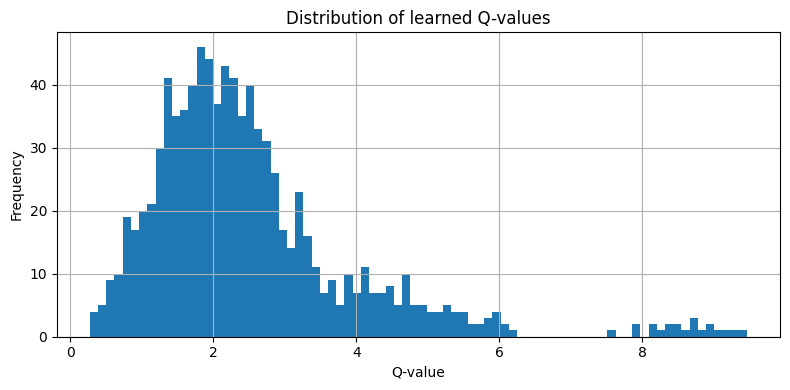

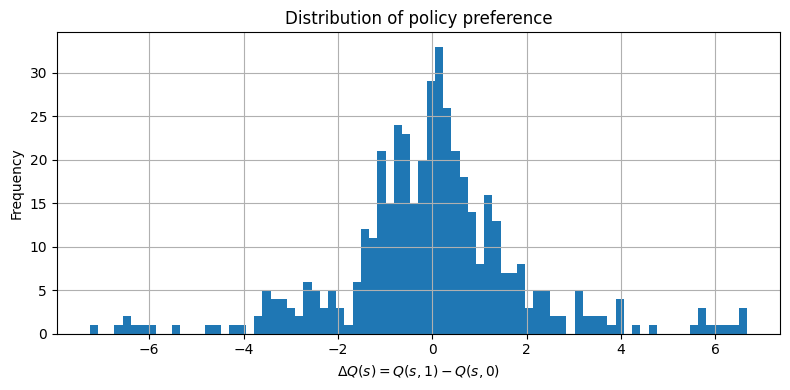

In [ ]:
# =========================================================
# Shared Q-table visualisation block
# Paste this after training, after Q has been generated.
#
# Your state encoding is:
#   state = (public_hist * phase_size + phase) * 2^reward_hist_len + reward_hist_code
#
# Therefore each state corresponds to:
#   public history h_t
#   phase phi_i(t)
#   recent reward history code
# =========================================================

import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# 1. Basic state decoding and Q-table slicing functions
# =========================================================

def state_id(public_hist, phase, reward_code, phase_size, reward_hist_len):
    """
    Convert (public_hist, phase, reward_code) into the integer state index.

    This must match the encode_state function in your environment:
        state = (public_hist * phase_size + phase) * 2^reward_hist_len + reward_code
    """
    reward_states = 2 ** reward_hist_len
    return (public_hist * phase_size + phase) * reward_states + reward_code


def binary_label(x, width):
    """
    Convert an integer into a fixed-width binary string.

    Example:
        binary_label(3, 4) -> '0011'
    """
    return format(int(x), f"0{width}b")


def q_slice_grid(Q, m, phase_size, reward_hist_len, reward_code=0, mode="delta"):
    """
    Create a 2D grid from the shared Q-table.

    Rows:
        phase phi

    Columns:
        public history h

    Fixed:
        reward history code

    mode options:
        "q0"         : Q(s, action=0)
        "q1"         : Q(s, action=1)
        "delta"      : Q(s,1) - Q(s,0)
        "max"        : max_a Q(s,a)
        "confidence" : |Q(s,1) - Q(s,0)|

    The most useful mode for policy interpretation is:
        mode = "delta"
    """
    n_hist = 2 ** m
    grid = np.zeros((phase_size, n_hist))

    for h in range(n_hist):
        for phi in range(phase_size):
            s = state_id(
                public_hist=h,
                phase=phi,
                reward_code=reward_code,
                phase_size=phase_size,
                reward_hist_len=reward_hist_len
            )

            if mode == "q0":
                value = Q[s, 0]

            elif mode == "q1":
                value = Q[s, 1]

            elif mode == "delta":
                value = Q[s, 1] - Q[s, 0]

            elif mode == "max":
                value = np.max(Q[s])

            elif mode == "confidence":
                value = abs(Q[s, 1] - Q[s, 0])

            else:
                raise ValueError(
                    "Unknown mode. Use one of: q0, q1, delta, max, confidence."
                )

            grid[phi, h] = value

    return grid


# =========================================================
# 2. Plot one Q-table slice
# =========================================================

def plot_q_slice(
    Q,
    m,
    phase_size,
    reward_hist_len,
    reward_code=0,
    mode="delta",
    figsize=(9, 4),
    title=None
):
    """
    Plot one decoded Q-table slice for a fixed reward history code.

    Recommended modes:
        mode="delta"
            shows policy preference.

        mode="confidence"
            shows how strong the action preference is.

        mode="max"
            shows the maximum learned Q-value.
    """
    grid = q_slice_grid(
        Q=Q,
        m=m,
        phase_size=phase_size,
        reward_hist_len=reward_hist_len,
        reward_code=reward_code,
        mode=mode
    )

    plt.figure(figsize=figsize)

    # For delta Q, use symmetric scale around zero.
    # Positive value means action 1 is preferred.
    # Negative value means action 0 is preferred.
    if mode == "delta":
        vmax = np.max(np.abs(grid))

        if vmax == 0:
            vmax = 1e-8

        vmin = -vmax
    else:
        vmin = None
        vmax = None

    im = plt.imshow(
        grid,
        aspect="auto",
        origin="lower",
        vmin=vmin,
        vmax=vmax
    )

    plt.colorbar(im, label=mode)

    hist_labels = [binary_label(h, m) for h in range(2 ** m)]
    phase_labels = [str(p) for p in range(phase_size)]

    plt.xticks(
        ticks=np.arange(2 ** m),
        labels=hist_labels,
        rotation=90
    )

    plt.yticks(
        ticks=np.arange(phase_size),
        labels=phase_labels
    )

    plt.xlabel("Public history $h_t$")
    plt.ylabel("Phase $\\phi_i(t)$")

    reward_label = binary_label(reward_code, reward_hist_len)

    if title is None:
        title = f"Q-table slice: mode={mode}, reward history={reward_label}"

    plt.title(title)
    plt.tight_layout()
    plt.show()


# =========================================================
# 3. Plot all reward-history slices
# =========================================================

def plot_all_reward_slices(
    Q,
    m,
    phase_size,
    reward_hist_len,
    mode="delta",
    figsize=(14, 8)
):
    """
    Plot Q-table slices for all reward history codes.

    If reward_hist_len = 3, then there are 2^3 = 8 reward-history states.

    Each subplot fixes one reward history code.
    Rows inside each subplot:
        phase

    Columns inside each subplot:
        public history
    """
    n_reward_states = 2 ** reward_hist_len
    ncols = 4
    nrows = int(np.ceil(n_reward_states / ncols))

    grids = []

    for r_code in range(n_reward_states):
        grid = q_slice_grid(
            Q=Q,
            m=m,
            phase_size=phase_size,
            reward_hist_len=reward_hist_len,
            reward_code=r_code,
            mode=mode
        )
        grids.append(grid)

    # Use a shared colour scale across all reward-history slices.
    if mode == "delta":
        global_abs = max(np.max(np.abs(g)) for g in grids)

        if global_abs == 0:
            global_abs = 1e-8

        vmin, vmax = -global_abs, global_abs

    else:
        vmin = min(np.min(g) for g in grids)
        vmax = max(np.max(g) for g in grids)

        if vmin == vmax:
            vmax = vmin + 1e-8

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    im = None

    for r_code, ax in enumerate(axes):
        if r_code >= n_reward_states:
            ax.axis("off")
            continue

        grid = grids[r_code]

        im = ax.imshow(
            grid,
            aspect="auto",
            origin="lower",
            vmin=vmin,
            vmax=vmax
        )

        reward_label = binary_label(r_code, reward_hist_len)
        ax.set_title(f"reward hist = {reward_label}")

        ax.set_xlabel("history")
        ax.set_ylabel("phase")

        ax.set_xticks(np.arange(2 ** m))
        ax.set_xticklabels(
            [binary_label(h, m) for h in range(2 ** m)],
            rotation=90,
            fontsize=7
        )

        ax.set_yticks(np.arange(phase_size))
        ax.set_yticklabels(
            [str(p) for p in range(phase_size)],
            fontsize=8
        )

    fig.suptitle(f"Shared Q-table slices, mode = {mode}", fontsize=14)

    if im is not None:
        fig.colorbar(im, ax=axes.tolist(), shrink=0.8, label=mode)

    plt.tight_layout()
    plt.show()


# =========================================================
# 4. Q-table density and distribution diagnostics
# =========================================================

def q_table_density_report(Q, thresholds=(1e-6, 1e-4, 1e-3, 1e-2, 0.1, 1)):
    """
    Print the density of the Q-table under different thresholds.

    Raw density:
        percentage of entries with |Q(s,a)| > epsilon

    This helps show that the learned Q-table is dense.
    """
    total_entries = Q.size

    print("=================================================")
    print("Q-table density report")
    print("=================================================")
    print("Q-table shape:", Q.shape)
    print("Total number of Q-values:", total_entries)
    print()

    for eps in thresholds:
        density = np.mean(np.abs(Q) > eps)
        nonzero_count = np.sum(np.abs(Q) > eps)

        print(
            f"Threshold |Q| > {eps:g}: "
            f"density = {density:.4f}, "
            f"count = {nonzero_count}/{total_entries}"
        )

    print("=================================================")


def plot_q_value_distribution(Q, bins=80, figsize=(8, 4)):
    """
    Plot the distribution of all Q-values.

    This shows whether Q-values are concentrated near zero
    or spread across a wider range.
    """
    values = Q.flatten()

    plt.figure(figsize=figsize)
    plt.hist(values, bins=bins)
    plt.xlabel("Q-value")
    plt.ylabel("Frequency")
    plt.title("Distribution of learned Q-values")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_q_delta_distribution(Q, bins=80, figsize=(8, 4)):
    """
    Plot the distribution of action preferences:

        Delta Q(s) = Q(s,1) - Q(s,0)

    This is often more meaningful than raw Q-value density.
    """
    delta = Q[:, 1] - Q[:, 0]

    plt.figure(figsize=figsize)
    plt.hist(delta, bins=bins)
    plt.xlabel(r"$\Delta Q(s) = Q(s,1) - Q(s,0)$")
    plt.ylabel("Frequency")
    plt.title("Distribution of policy preference")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def effective_policy_density_report(Q, thresholds=(1e-3,1e-2, 5e-2, 1e-1, 1, 2, 5)):
    """
    Report how many states have a meaningful action preference.

    Effective policy density is based on:

        |Q(s,1) - Q(s,0)| > threshold

    This is useful because a Q-table can be dense in raw values,
    but many states may still have weak action preferences.
    """
    delta = Q[:, 1] - Q[:, 0]
    total_states = Q.shape[0]

    print("=================================================")
    print("Effective policy density report")
    print("=================================================")
    print("Total number of states:", total_states)
    print()

    for eps in thresholds:
        density = np.mean(np.abs(delta) > eps)
        count = np.sum(np.abs(delta) > eps)

        print(
            f"Threshold |Delta Q| > {eps:g}: "
            f"density = {density:.4f}, "
            f"count = {count}/{total_states}"
        )

    print("=================================================")


# =========================================================
# Example usage for your current experiment
# =========================================================
# Your current experiment uses:
#   m = 3
#   n_agents = 7
#   reward_hist_len = 3
#   phase_size = 7
#
# If you change these in training, change them here as well.
# =========================================================

m_vis = 3
phase_size_vis = 7
reward_hist_len_vis = 3


# ---------------------------------------------------------
# Single reward-history slice
# ---------------------------------------------------------

plot_q_slice(
    Q=Q,
    m=m_vis,
    phase_size=phase_size_vis,
    reward_hist_len=reward_hist_len_vis,
    reward_code=0,
    mode="delta",
    title="Policy preference: Q(s,1) - Q(s,0)"
)

plot_q_slice(
    Q=Q,
    m=m_vis,
    phase_size=phase_size_vis,
    reward_hist_len=reward_hist_len_vis,
    reward_code=0,
    mode="confidence",
    title="Decision confidence: |Q(s,1) - Q(s,0)|"
)

plot_q_slice(
    Q=Q,
    m=m_vis,
    phase_size=phase_size_vis,
    reward_hist_len=reward_hist_len_vis,
    reward_code=0,
    mode="max",
    title="Maximum learned value: max_a Q(s,a)"
)


# ---------------------------------------------------------
# All reward-history slices
# ---------------------------------------------------------

plot_all_reward_slices(
    Q=Q,
    m=m_vis,
    phase_size=phase_size_vis,
    reward_hist_len=reward_hist_len_vis,
    mode="delta",
    figsize=(14, 8)
)

plot_all_reward_slices(
    Q=Q,
    m=m_vis,
    phase_size=phase_size_vis,
    reward_hist_len=reward_hist_len_vis,
    mode="confidence",
    figsize=(14, 8)
)


# ---------------------------------------------------------
# Density and distribution diagnostics
# ---------------------------------------------------------

q_table_density_report(Q)

effective_policy_density_report(Q)

plot_q_value_distribution(Q)

plot_q_delta_distribution(Q)

In [ ]:
def run_shared_q_phase(
    m=3,
    n_agents=7,
    steps=200000,
    seed=42,
    alpha=0.10,
    gamma=0.95,
    tau_start=1.0,
    tau_end=0.02,
    tau_decay=0.99995,
    reward_hist_len=3,
    phase_size=7,
    log_window=1000
):
    env = MinorityGameSharedQPhase(
        m=m,
        n_agents=n_agents,
        reward_hist_len=reward_hist_len,
        phase_size=phase_size,
        seed=seed
    )

    n_states = (2 ** m) * env.phase_size * (2 ** reward_hist_len)
    n_actions = 2

    Q = np.zeros((n_states, n_actions), dtype=float)

    # New: visitation counters
    visit_counts = np.zeros((n_states, n_actions), dtype=int)
    state_visit_counts = np.zeros(n_states, dtype=int)

    states = env.reset()
    tau = tau_start

    rewards_hist = np.zeros((steps, n_agents), dtype=float)
    actions_hist = np.zeros((steps, n_agents), dtype=int)
    minority_hist = np.zeros(steps, dtype=int)
    tau_hist = np.zeros(steps, dtype=float)

    for t in range(steps):
        actions = np.zeros(n_agents, dtype=int)

        # all agents use the same Q-table
        for i in range(n_agents):
            actions[i] = softmax_action(Q, states[i], tau, env.rng)

        # New: record state-action visitation before transition
        for i in range(n_agents):
            s = states[i]
            a = actions[i]
            visit_counts[s, a] += 1
            state_visit_counts[s] += 1

        next_states, rewards, minority_action = env.step(actions)

        # shared Q update
        for i in range(n_agents):
            s = states[i]
            a = actions[i]
            r = rewards[i]
            s_next = next_states[i]

            td_target = r + gamma * np.max(Q[s_next])
            Q[s, a] += alpha * (td_target - Q[s, a])

        rewards_hist[t] = rewards
        actions_hist[t] = actions
        minority_hist[t] = minority_action
        tau_hist[t] = tau

        states = next_states
        tau = max(tau_end, tau * tau_decay)

    rolling_rewards = np.full((steps, n_agents), np.nan)

    if log_window <= steps:
        kernel = np.ones(log_window) / log_window
        for i in range(n_agents):
            rolling_rewards[log_window - 1:, i] = np.convolve(
                rewards_hist[:, i],
                kernel,
                mode="valid"
            )

    return (
        Q,
        rewards_hist,
        actions_hist,
        minority_hist,
        rolling_rewards,
        tau_hist,
        visit_counts,
        state_visit_counts
    )
Q, rewards_hist,actions_hist, minority_hist, rolling_rewards, tau_hist, visit_counts, state_visit_counts=run_shared_q_phase()

In [ ]:
# =========================================================
# Visualise relation between state visitation and Delta Q
# =========================================================

import numpy as np
import matplotlib.pyplot as plt


def plot_delta_q_vs_visits(Q, state_visit_counts, log_x=True):
    """
    Scatter plot:
        x-axis: number of visits to state s
        y-axis: Delta Q(s) = Q(s,1) - Q(s,0)

    This shows whether strong policy preferences mainly appear
    in frequently visited states or rarely visited states.
    """
    delta_q = Q[:, 1] - Q[:, 0]
    visits = state_visit_counts

    if log_x:
        x = np.log1p(visits)
        xlabel = "log(1 + state visit count)"
    else:
        x = visits
        xlabel = "State visit count"

    plt.figure(figsize=(8, 5))
    plt.scatter(x, delta_q, alpha=0.6, s=20)
    plt.axhline(0, linestyle="--", linewidth=1)

    plt.xlabel(xlabel)
    plt.ylabel(r"$\Delta Q(s) = Q(s,1) - Q(s,0)$")
    plt.title("Policy preference against state visitation")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_abs_delta_q_vs_visits(Q, state_visit_counts, log_x=True):
    """
    Scatter plot:
        x-axis: number of visits to state s
        y-axis: |Delta Q(s)|

    This directly shows decision confidence against visitation.
    """
    delta_q = Q[:, 1] - Q[:, 0]
    abs_delta_q = np.abs(delta_q)
    visits = state_visit_counts

    if log_x:
        x = np.log1p(visits)
        xlabel = "log(1 + state visit count)"
    else:
        x = visits
        xlabel = "State visit count"

    plt.figure(figsize=(8, 5))
    plt.scatter(x, abs_delta_q, alpha=0.6, s=20)

    plt.xlabel(xlabel)
    plt.ylabel(r"$|\Delta Q(s)|$")
    plt.title("Decision confidence against state visitation")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_binned_abs_delta_q_vs_visits(Q, state_visit_counts, n_bins=10):
    """
    Bin states by visit count and plot the average |Delta Q(s)| in each bin.

    This is cleaner than the raw scatter plot and is useful for the report.
    """
    delta_q = Q[:, 1] - Q[:, 0]
    abs_delta_q = np.abs(delta_q)
    visits = state_visit_counts

    visited_mask = visits > 0

    visits = visits[visited_mask]
    abs_delta_q = abs_delta_q[visited_mask]

    log_visits = np.log1p(visits)

    bins = np.linspace(log_visits.min(), log_visits.max(), n_bins + 1)

    bin_centres = []
    bin_means = []
    bin_counts = []

    for k in range(n_bins):
        left = bins[k]
        right = bins[k + 1]

        if k == n_bins - 1:
            mask = (log_visits >= left) & (log_visits <= right)
        else:
            mask = (log_visits >= left) & (log_visits < right)

        if np.sum(mask) == 0:
            continue

        bin_centres.append((left + right) / 2)
        bin_means.append(abs_delta_q[mask].mean())
        bin_counts.append(np.sum(mask))

    plt.figure(figsize=(8, 5))
    plt.plot(bin_centres, bin_means, marker="o")

    plt.xlabel("Binned log(1 + state visit count)")
    plt.ylabel(r"Average $|\Delta Q(s)|$")
    plt.title("Average decision confidence by visitation level")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("Bin summary:")
    for c, m, count in zip(bin_centres, bin_means, bin_counts):
        print(
            f"log-visit centre={c:.3f}, "
            f"mean |Delta Q|={m:.4f}, "
            f"number of states={count}"
        )


def visit_delta_summary(Q, state_visit_counts, thresholds=(1, 10, 100, 1000)):
    """
    Print summary statistics of |Delta Q(s)| for states visited more than
    different thresholds.
    """
    delta_q = Q[:, 1] - Q[:, 0]
    abs_delta_q = np.abs(delta_q)

    print("=================================================")
    print("Visit-count vs policy-confidence summary")
    print("=================================================")

    for threshold in thresholds:
        mask = state_visit_counts >= threshold

        if np.sum(mask) == 0:
            print(f"States with visits >= {threshold}: none")
            continue

        print(f"States with visits >= {threshold}:")
        print(f"  count = {np.sum(mask)}")
        print(f"  mean |Delta Q| = {abs_delta_q[mask].mean():.4f}")
        print(f"  median |Delta Q| = {np.median(abs_delta_q[mask]):.4f}")
        print(f"  max |Delta Q| = {abs_delta_q[mask].max():.4f}")
        print()

    print("=================================================")


def plot_visit_count_distribution(state_visit_counts, bins=80):
    """
    Plot distribution of state visitation counts.
    """
    plt.figure(figsize=(8, 4))
    plt.hist(state_visit_counts, bins=bins)
    plt.xlabel("State visit count")
    plt.ylabel("Frequency")
    plt.title("Distribution of state visitation counts")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_log_visit_count_distribution(state_visit_counts, bins=80):
    """
    Plot distribution of log state visitation counts.
    """
    log_visits = np.log1p(state_visit_counts)

    plt.figure(figsize=(8, 4))
    plt.hist(log_visits, bins=bins)
    plt.xlabel("log(1 + state visit count)")
    plt.ylabel("Frequency")
    plt.title("Distribution of log state visitation counts")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

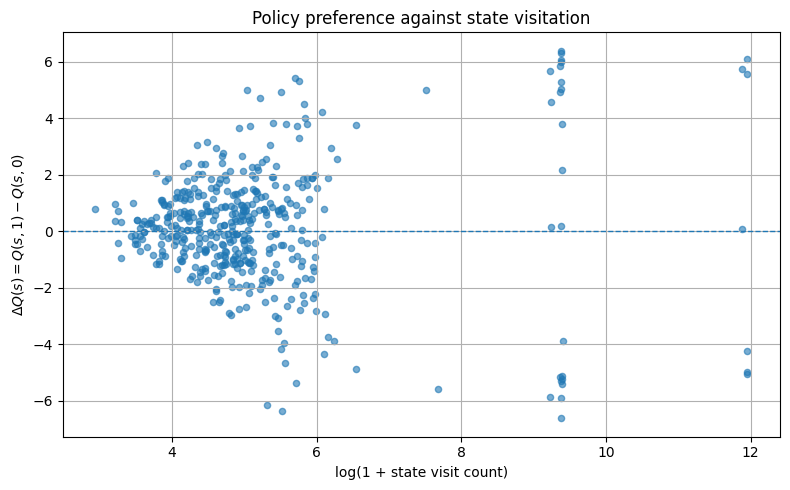

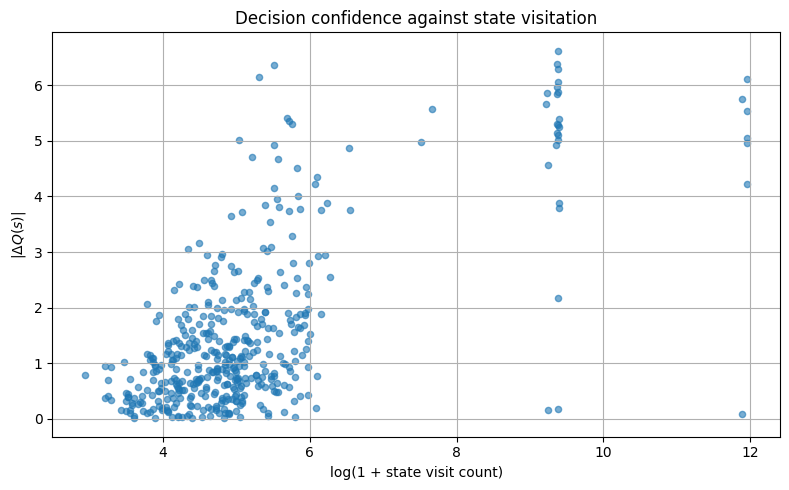

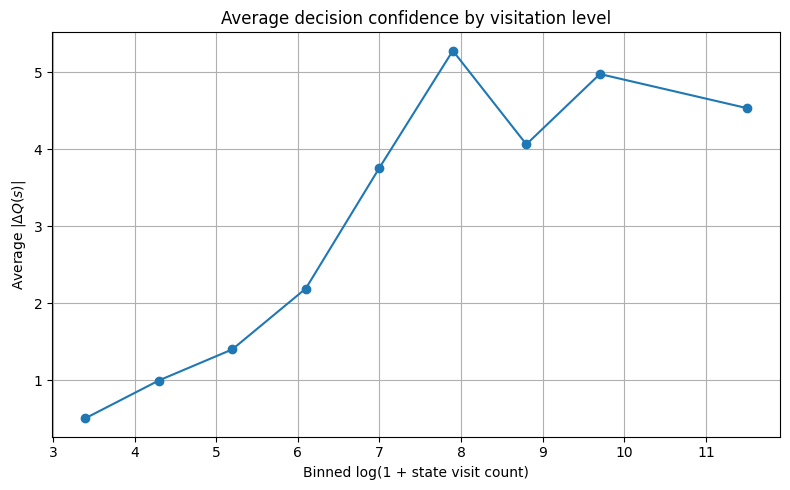

Bin summary:
log-visit centre=3.395, mean |Delta Q|=0.5066, number of states=37
log-visit centre=4.296, mean |Delta Q|=0.9976, number of states=160
log-visit centre=5.197, mean |Delta Q|=1.4014, number of states=163
log-visit centre=6.098, mean |Delta Q|=2.1913, number of states=55
log-visit centre=6.999, mean |Delta Q|=3.7562, number of states=1
log-visit centre=7.900, mean |Delta Q|=5.2778, number of states=2
log-visit centre=8.800, mean |Delta Q|=4.0624, number of states=4
log-visit centre=9.701, mean |Delta Q|=4.9752, number of states=19
log-visit centre=11.503, mean |Delta Q|=4.5329, number of states=7


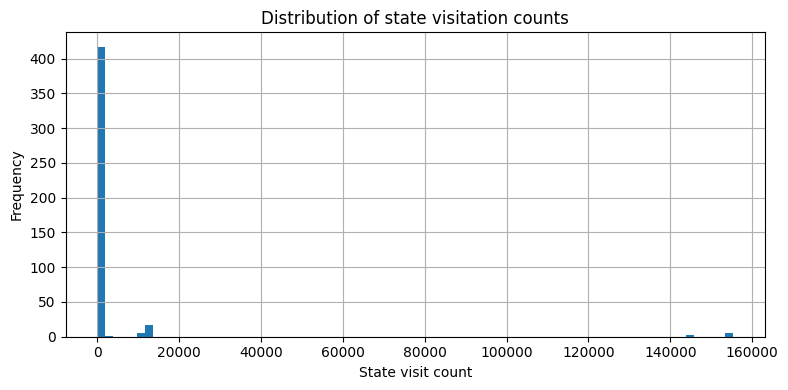

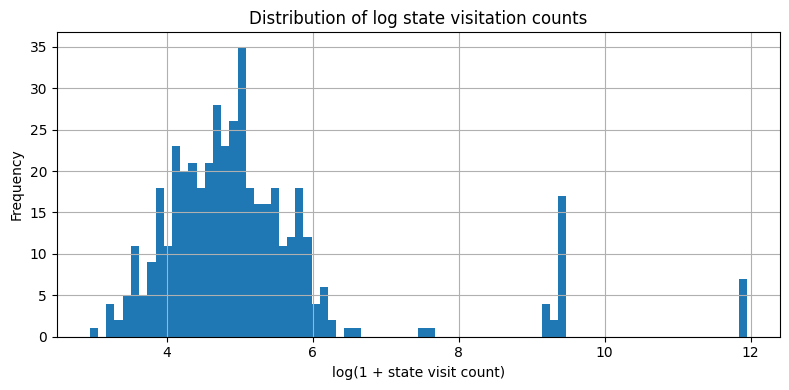

Visit-count vs policy-confidence summary
States with visits >= 1:
  count = 448
  mean |Delta Q| = 1.5271
  median |Delta Q| = 1.0469
  max |Delta Q| = 6.6219

States with visits >= 10:
  count = 448
  mean |Delta Q| = 1.5271
  median |Delta Q| = 1.0469
  max |Delta Q| = 6.6219

States with visits >= 100:
  count = 285
  mean |Delta Q| = 1.9217
  median |Delta Q| = 1.3875
  max |Delta Q| = 6.6219

States with visits >= 1000:
  count = 32
  mean |Delta Q| = 4.7833
  median |Delta Q| = 5.2642
  max |Delta Q| = 6.6219

States with visits >= 5000:
  count = 30
  mean |Delta Q| = 4.7503
  median |Delta Q| = 5.2642
  max |Delta Q| = 6.6219



In [ ]:
plot_delta_q_vs_visits(Q, state_visit_counts)

plot_abs_delta_q_vs_visits(Q, state_visit_counts)

plot_binned_abs_delta_q_vs_visits(Q, state_visit_counts, n_bins=10)

plot_visit_count_distribution(state_visit_counts)

plot_log_visit_count_distribution(state_visit_counts)

visit_delta_summary(
    Q,
    state_visit_counts,
    thresholds=(1, 10, 100, 1000, 5000)
)